In [1]:
%load_ext autoreload
%autoreload 2

import os
os.environ["OPENBLAS_NUM_THREADS"] = "4"  # or a lower number like 2, 4, or 8

import sys, re, torch, time, PINN, palantir
import numpy as np
import pandas as pd
import scanpy as sc
from tqdm.auto import tqdm
# PINN
from PINN import reader, models, pl, tl
# plot
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
from matplotlib.backends.backend_pdf import PdfPages

os.chdir("/ssd/users/Wergillius/Project/PINN_dynamics")

# load data

In [2]:
ad_palantir = sc.read_h5ad("data/tom_pos_palantir_Jun4.h5ad")
ad_palantir

AnnData object with n_obs × n_vars = 49390 × 4814
    obs: 'n_genes', 'n_counts', 'mt_count', 'mt_frac', 'doublet_scores', 'predicted_doublets', 'xist_logn', 'Ygene_logn', 'xist_bin', 'Ygene_bin', 'sex_adata', 'biosample_id', 'cellid', 'RBG', 'SLXid', 'index', '10xsample_description', 'sex_mixed', 'sex_meta', 'mouse_id', 'sortedcells', 'expected_cells_10x', 'cellranger_cellsfound', 'chemistry', 'tom', 'expdate', 'batch', 'timepoint_tx_days', 'start_age', 'sample_id', 'countfile', 'S_score', 'G2M_score', 'phase', 'leiden', 'SLX', 'plate_sorted', 'plate_rearranged', 'well_sorted', 'well_rearranged', 'set_index', 'CI_index', 'mouse_platelabel', 'sort_method', 'sample.name', 'population', 'sex', 'countfolder', 'batch_plate_sorted', 'data_type', 'sex_combined', 'longname', 'anno_man', 'leiden_DM', 'HSCscore', 'nn_HSCscore', 'isroot', 'dpt_pseudotime', 'leiden_orig', 'logk', 'net_prolif', 'log10SR', 'log_density_at_E3', 'log_density_at_E7', 'log_density_at_E12', 'log_density_at_E12_clip', 'l

In [3]:
adata_lin = {}
v_project = {}
g_project = {}
x_project = {}
pdt_bin_lineage = {}

for lineage in ['Neu', 'Meg', 'Ery']:
    ad = ad_palantir[ad_palantir.obsm['branch_masks'][lineage]].copy()
    pdt_max = ad.obs['palantir_pseudotime'].max()

    # Normalize the pseudotime
    x = np.linspace(0, pdt_max, 100)
    x_project[lineage] = (x[1:] + x[:-1])/2
    v_project[lineage] = tl.aggregate_params_by_pseudotime(ad, ad.obsm['v_norm'].T, 
                                            param_names='v', timepoints=None, 
                                            pseudotime_key='palantir_pseudotime',
                                            nbins=100, return_y=True)

    g_project[lineage] = tl.aggregate_params_by_pseudotime(ad, ad.obsm['g'].T, 
                                            param_names='g', timepoints=None, 
                                            pseudotime_key='palantir_pseudotime',
                                            nbins=100, return_y=True)

    pdt_bins = np.linspace(0, pdt_max, 21)
    pdt_bin_lineage[lineage] = pdt_bins
    pdt_label = np.round((pdt_bins[1:] + pdt_bins[:-1])/2, 2)
    ad.obs['pseudotime_bin'] = pd.cut(ad.obs['palantir_pseudotime']
                                            ,bins=20,labels = pdt_label).astype(float)
    
    adata_lin[lineage] = ad
    print(adata_lin[lineage].obs['pseudotime_bin'].unique())

[0.39 0.67 0.35 0.3  0.44 0.25 0.53 0.48 0.58 0.62 0.21 0.81 0.76 0.9
 0.07 0.16 0.71 0.85 0.12 0.02]
[0.34 0.37 0.26 0.28 0.42 0.39 0.31 0.45 0.47 0.23 0.53 0.5  0.07 0.18
 0.15 0.2  0.12 0.09 0.04 0.01]
[0.38 0.32 0.45 0.55 0.25 0.58 0.42 0.28 0.62 0.35 0.52 0.48 0.65 0.22
 0.08 0.18 0.15 0.12 0.05 0.02]


# Neu

In [ ]:
# pdt_max = adata_lin['Neu'].obs['palantir_pseudotime'].max()

# pdt_bins = np.linspace(0, pdt_max, 21)
# pdt_bin_lineage['Neu'] = pdt_bins
# pdt_label = np.round((pdt_bins[1:] + pdt_bins[:-1])/2, 2)
# adata_lin['Neu'].obs['pseudotime_bin'] = pd.cut(adata_lin['Neu'].obs['palantir_pseudotime']
#                                                     , bins=20,labels = pdt_label)


[0.39 0.67 0.35 0.3  0.44 0.25 0.53 0.48 0.58 0.62 0.21 0.81 0.76 0.9
 0.07 0.16 0.71 0.85 0.12 0.02]


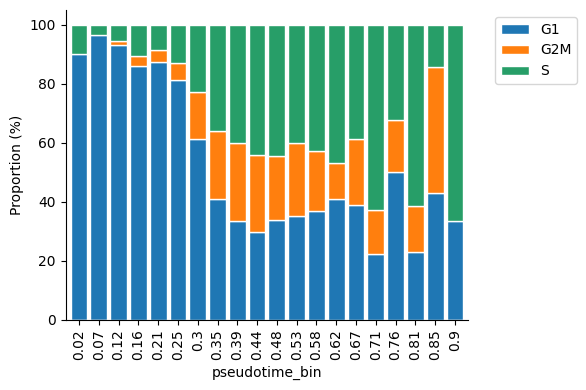

In [28]:
ad = adata_lin['Neu']
print(ad.obs['pseudotime_bin'].unique())
fig, ax = pl.obs_composition(ad[ad.obs['timepoint_tx_days']<=76],
                             x_var='pseudotime_bin',y_var='phase')

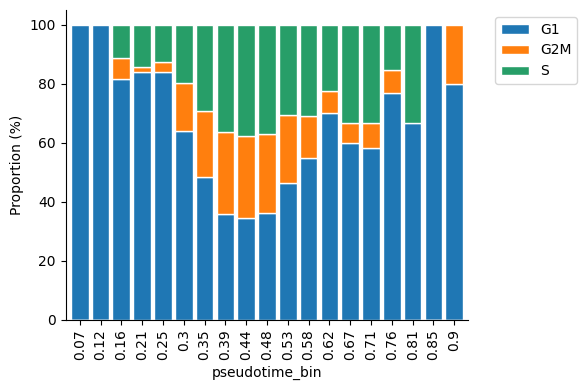

In [6]:
ad = adata_lin['Neu']
fig, ax = pl.obs_composition(ad[ad.obs['timepoint_tx_days']>76],
                             x_var='pseudotime_bin',y_var='phase')

In [7]:
adata_lin['Neu']

AnnData object with n_obs × n_vars = 23442 × 4814
    obs: 'n_genes', 'n_counts', 'mt_count', 'mt_frac', 'doublet_scores', 'predicted_doublets', 'xist_logn', 'Ygene_logn', 'xist_bin', 'Ygene_bin', 'sex_adata', 'biosample_id', 'cellid', 'RBG', 'SLXid', 'index', '10xsample_description', 'sex_mixed', 'sex_meta', 'mouse_id', 'sortedcells', 'expected_cells_10x', 'cellranger_cellsfound', 'chemistry', 'tom', 'expdate', 'batch', 'timepoint_tx_days', 'start_age', 'sample_id', 'countfile', 'S_score', 'G2M_score', 'phase', 'leiden', 'SLX', 'plate_sorted', 'plate_rearranged', 'well_sorted', 'well_rearranged', 'set_index', 'CI_index', 'mouse_platelabel', 'sort_method', 'sample.name', 'population', 'sex', 'countfolder', 'batch_plate_sorted', 'data_type', 'sex_combined', 'longname', 'anno_man', 'leiden_DM', 'HSCscore', 'nn_HSCscore', 'isroot', 'dpt_pseudotime', 'leiden_orig', 'logk', 'net_prolif', 'log10SR', 'log_density_at_E3', 'log_density_at_E7', 'log_density_at_E12', 'log_density_at_E12_clip', 'l

In [106]:
# Compute cell cycle proportion and average G2M score along pseudotime bins for each lineage

def plot_cellcycle_growth(timepoint_i, save_path=None):
    """
    Plot cell cycle proportions and G2M scores along pseudotime for a given timepoint index.
    Args:
        timepoint_i (int): Index of the timepoint to plot.
    """
    dpi = 80 if save_path is None else 600
    day = ad_palantir.uns['pop']['t'][timepoint_i]
    cell_cycle_props = {}
    g2m_means = {}
    sscore_means = {}
    bin_centers = {}

    for lineage, ad in adata_lin.items():
        # Get pseudotime and G2M score

        ad_day = ad[ad.obs['timepoint_tx_days'] == day].copy()
        pdt = ad_day.obs['palantir_pseudotime'].values
        g2m = ad_day.obs['G2M_score'].values
        sscore = ad_day.obs['S_score'].values

        # Define bins
        bins = np.linspace(pdt.min(), pdt.max(), 11)
        bin_labels = 0.5 * (bins[:-1] + bins[1:])

        # Compute cell cycle proportion (S or G2M phase)
        is_cc = ad_day.obs['phase'].isin(['S', 'G2M']).values
        prop = []
        g2m_avg = []
        sscore_avg = []

        valided_bins = []
        for i in range(len(bins)-1):
            mask = (pdt >= bins[i]) & (pdt < bins[i+1])
            if mask.sum() > 0:
                prop.append(is_cc[mask].mean())
                g2m_avg.append(g2m[mask].mean())
                sscore_avg.append(sscore[mask].mean())
                valided_bins.append(bin_labels[i])
            # else:
            #     prop.append(np.nan)
            #     g2m_avg.append(np.nan)
            #     sscore_avg.append(np.nan)

        cell_cycle_props[lineage] = np.array(prop)
        g2m_means[lineage] = np.array(g2m_avg)  
        sscore_means[lineage] = np.array(sscore_avg)  

        bin_centers[lineage] = valided_bins

    # Plotting
    fig, axs = plt.subplots(2, 3, figsize=(13, 5), dpi=dpi,
                             gridspec_kw={'hspace':0.4, 'wspace':0.7})

    for idx, lineage in enumerate(['Neu', 'Meg', 'Ery']):
        # Cell cycle proportion
        ad = adata_lin[lineage]
        ad_day = ad[ad.obs['timepoint_tx_days'] == day].copy()
        pl.obs_composition(ad_day,x_var='pseudotime_bin',y_var='phase',
                                ax=axs[0,idx])
        

        # G2M score and g_project
        axs[1,idx].plot(bin_centers[lineage], g2m_means[lineage], color='blue', marker='o', label=f'G2M score')
        # axs[1,idx].plot(bin_centers[lineage], sscore_means[lineage], color='orange', marker='o', label=f'Day{day} S score')
        
        # only plot 
        pdt_mask = np.logical_and(x_project[lineage]>=bin_centers[lineage][0],
                                  x_project[lineage]<=bin_centers[lineage][-1])
        ax2 = axs[1,idx].twinx()
        ax2.plot(x_project[lineage][pdt_mask], g_project[lineage][0][pdt_mask], color='green', label=f'growth')

        # ax3 = axs[idx].twinx()
        # ax3.plot(x_project[lineage], g_project[lineage][-2], color='orange', label='Day161 Growth')
        axs[0,idx].set_title(f"{lineage} Day{day} \n cell cycle phase & growth")
        axs[0,idx].set_ylabel('Cell cycle phase\n proportion')
        axs[1,idx].set_ylabel('Average G2M score')
        ax2.set_ylabel('Growth')
        axs[0,idx].set_xlabel('')
        axs[1,idx].set_xlabel('Pseudotime')

        
    
        # ax2.legend(frameon=False)

    axs[0,0].legend([], frameon=False)
    axs[0,1].legend([], frameon=False)

    # get the legend handle and label from ax2 and combine with axs[1,idx]
    handles1, labels1 = axs[1,idx].get_legend_handles_labels()
    handles2, labels2 = ax2.get_legend_handles_labels()
    axs[1,idx].legend(handles1+handles2, labels1+labels2, loc="lower right")

    plt.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, transparent=True)
    # plt.show()
    return fig

/ssd/users/Wergillius/Project/PINN_dynamics/PINN/plotting_fns/density_plot.py:302: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  return fig, ax
/ssd/users/Wergillius/Project/PINN_dynamics/PINN/plotting_fns/density_plot.py:302: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  return fig, ax
/ssd/users/Wergillius/Project/PINN_dynamics/PINN/plotting_fns/density_plot.py:302: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  return fig, ax
/tmp/ipykernel_1214856/175842864.py:96: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


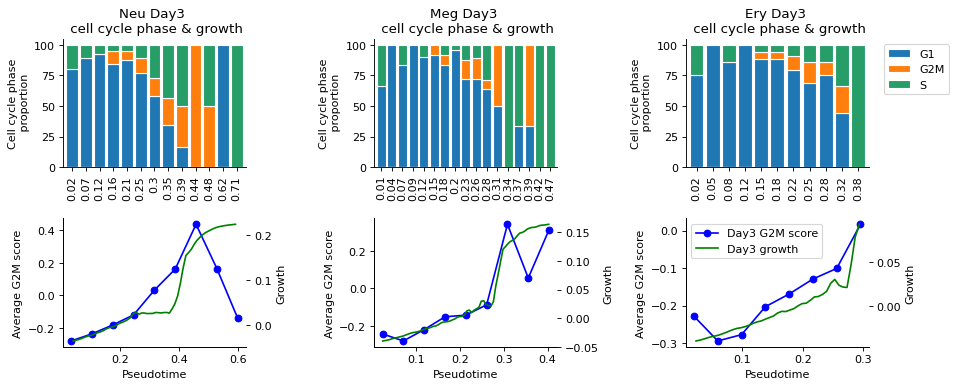

In [102]:
fig = plot_cellcycle_growth(0)

In [107]:
plt.ioff()
for i in range(1,9):
    day = ad_palantir.uns['pop']['t'][i]
    fig = plot_cellcycle_growth(i, 
    save_path=f'figures/tompos_growth_cellcycle/Day{day}_pdt.pdf')

    fig.show(False)

/ssd/users/Wergillius/Project/PINN_dynamics/PINN/plotting_fns/density_plot.py:302: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  return fig, ax
/ssd/users/Wergillius/Project/PINN_dynamics/PINN/plotting_fns/density_plot.py:302: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  return fig, ax
/ssd/users/Wergillius/Project/PINN_dynamics/PINN/plotting_fns/density_plot.py:302: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  return fig, ax
/tmp/ipykernel_1214856/1983356295.py:96: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/ssd/users/Wergillius/Project/PINN_dynamics/PINN/plotting_fns/density_plot.py:302: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be i